<a href="https://colab.research.google.com/github/tnwlvos/Purdue-AI-education-Muchine-Learning-/blob/main/FSSW_Audio_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FSSW 음향 기반 공정 상태 분류

FSSW 음향을 Log-Mel spectrogram으로 변환하고 CNN을 이용해 공정 상태를 분류한다.

현재 단계에서는 ON/OFF 이진 분류 모델을 개발한다. 이후 동일한 전처리와 CNN 구조를 확장해 OFF, Approach, Plunge, Dwell, Retract를 분류하는 단일 모델을 개발한다.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 라이브러리 불러오기

음원 처리, Mel-spectrogram 생성, 데이터 관리 및 시각화에 필요한 라이브러리를 불러온다.

In [ ]:
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf

## 프로젝트 경로와 최종 manifest 불러오기

데이터 준비 노트북에서 저장한 최종 `window_manifest.csv`를 불러온다.

이 manifest에는 각 1초 윈도우의 음원 경로, 시작 시각, ON/OFF 라벨과 데이터 분할 정보가 들어 있다.

In [ ]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/Friction Stir Spot Welding (FSSW)"
)

METADATA_DIR = (
    PROJECT_DIR / "[3] metadata"
)

WINDOW_MANIFEST_PATH = (
    METADATA_DIR / "window_manifest.csv"
)

window_manifest = pd.read_csv(
    WINDOW_MANIFEST_PATH
)

print(
    "전체 윈도우 수:",
    len(window_manifest),
)

display(
    pd.crosstab(
        window_manifest["dataset_role"],
        window_manifest["label"],
    )
)

display(
    window_manifest.head()
)

전체 윈도우 수: 4531


label,OFF,ON
dataset_role,,
development_A,702,807
development_B,702,809
test_holdout,702,809


,window_id,label,label_id,dataset_role,experiment_id,source_type,source_file,relative_path,side,start_sec,end_sec
0,window_00001,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[5] off/development_A...,after,0.0,1.0
1,window_00002,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[5] off/development_A...,after,0.5,1.5
2,window_00003,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[5] off/development_A...,after,1.0,2.0
3,window_00004,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[5] off/development_A...,after,1.5,2.5
4,window_00005,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[5] off/development_A...,after,2.0,3.0


## 음원 경로와 윈도우 정보 검증

Manifest의 상대경로를 실제 Google Drive 경로로 변환하고 모든 음원 파일이 존재하는지 확인한다.

또한 라벨, 데이터 분할 및 윈도우 길이가 올바른지 검사한다.

In [ ]:
window_manifest["full_path"] = (
    window_manifest["relative_path"]
    .apply(
        lambda path: str(
            PROJECT_DIR / path
        )
    )
)

missing_files = (
    window_manifest.loc[
        ~window_manifest["full_path"]
        .apply(
            lambda path: Path(path).exists()
        ),
        "full_path",
    ]
    .drop_duplicates()
)

window_durations = (
    window_manifest["end_sec"]
    - window_manifest["start_sec"]
)

print(
    "존재하지 않는 파일 수:",
    len(missing_files),
)

print(
    "윈도우 최소 길이:",
    window_durations.min(),
)

print(
    "윈도우 최대 길이:",
    window_durations.max(),
)

print(
    "라벨:",
    sorted(
        window_manifest["label"]
        .unique()
    ),
)

print(
    "데이터 분할:",
    sorted(
        window_manifest["dataset_role"]
        .unique()
    ),
)

존재하지 않는 파일 수: 0
윈도우 최소 길이: 1.0
윈도우 최대 길이: 1.0
라벨: ['OFF', 'ON']
데이터 분할: ['development_A', 'development_B', 'test_holdout']


## Log-Mel spectrogram 설정

1초 음향을 STFT로 분석한 뒤 64개의 Mel 주파수 구간으로 변환한다.

dB 변환에는 각 음원의 최대값이 아닌 고정 기준값을 사용한다. 음원마다 최대값으로 정규화하면 ON과 OFF의 중요한 음량 차이가 사라질 수 있기 때문이다.

샘플링레이트: 48,000 Hz

FFT 크기: 2,048 samples

STFT 이동 간격: 512 samples

Mel 필터 수: 64

분석 주파수: 50~12,000 Hz

In [ ]:
SAMPLE_RATE = 48000
WINDOW_SECONDS = 1.0

N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 64

FMIN = 50
FMAX = 12000

TOP_DB = 80


def load_audio_window(row):
    file_path = (
        PROJECT_DIR
        / row["relative_path"]
    )

    start_frame = int(
        round(
            row["start_sec"]
            * SAMPLE_RATE
        )
    )

    frame_count = int(
        round(
            WINDOW_SECONDS
            * SAMPLE_RATE
        )
    )

    with sf.SoundFile(
        str(file_path),
        "r",
    ) as audio_file:
        if audio_file.samplerate != SAMPLE_RATE:
            raise ValueError(
                f"샘플링레이트 오류: "
                f"{file_path.name}"
            )

        audio_file.seek(start_frame)

        signal = audio_file.read(
            frame_count,
            dtype="float32",
            always_2d=False,
        )

    if len(signal) != frame_count:
        raise ValueError(
            f"윈도우 길이 오류: "
            f"{file_path.name}, "
            f"{len(signal)} samples"
        )

    return signal


def make_log_mel(signal):
    mel_power = librosa.feature.melspectrogram(
        y=signal,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=N_FFT,
        window="hann",
        center=False,
        power=2.0,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
    )

    log_mel = librosa.power_to_db(
        mel_power,
        ref=1.0,
        top_db=TOP_DB,
    )

    return log_mel.astype(
        np.float32
    )

## 개발 데이터의 ON/OFF Mel-spectrogram 확인

최종 테스트 데이터는 사용하지 않고 development A에서 ON과 OFF 윈도우를 하나씩 선택한다.

두 이미지에 동일한 dB 색상 범위를 사용해 음량과 주파수 분포를 직접 비교한다.

OFF Log-Mel shape: (64, 90)
ON Log-Mel shape: (64, 90)


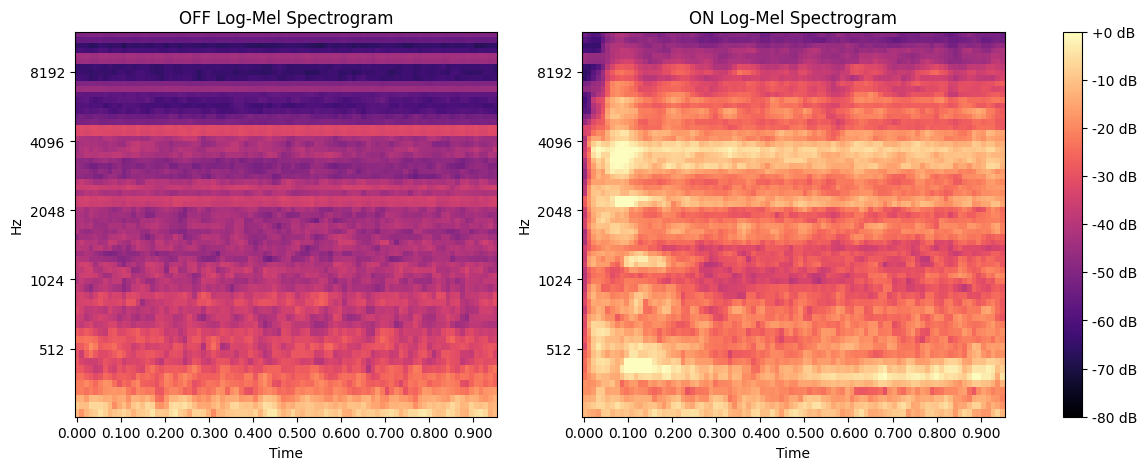

In [ ]:
off_example = (
    window_manifest[
        (
            window_manifest["dataset_role"]
            == "development_A"
        )
        & (
            window_manifest["label"]
            == "OFF"
        )
    ]
    .iloc[0]
)

on_example = (
    window_manifest[
        (
            window_manifest["dataset_role"]
            == "development_A"
        )
        & (
            window_manifest["label"]
            == "ON"
        )
    ]
    .iloc[0]
)

off_signal = load_audio_window(
    off_example
)

on_signal = load_audio_window(
    on_example
)

off_log_mel = make_log_mel(
    off_signal
)

on_log_mel = make_log_mel(
    on_signal
)

print(
    "OFF Log-Mel shape:",
    off_log_mel.shape,
)

print(
    "ON Log-Mel shape:",
    on_log_mel.shape,
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)

for axis, log_mel, title in [
    (
        axes[0],
        off_log_mel,
        "OFF Log-Mel Spectrogram",
    ),
    (
        axes[1],
        on_log_mel,
        "ON Log-Mel Spectrogram",
    ),
]:
    image = librosa.display.specshow(
        log_mel,
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        fmin=FMIN,
        fmax=FMAX,
        vmin=-80,
        vmax=0,
        cmap="magma",
        ax=axis,
    )

    axis.set_title(title)

fig.colorbar(
    image,
    ax=axes,
    format="%+2.0f dB",
)

plt.show()

## 전체 Log-Mel 데이터 생성 및 분할별 저장

모든 1초 오디오 윈도우를 동일한 설정의 Log-Mel spectrogram으로 변환한다.

WAV 파일을 윈도우마다 다시 열지 않고, 동일한 WAV 파일에 속한 윈도우를 한 번에 처리하여 Google Drive 읽기 시간을 줄인다.

데이터는 다음 세 파일로 분리해 저장한다.

- `development_A_logmel.npz`
- `development_B_logmel.npz`
- `test_holdout_logmel.npz`

현재 단계에서는 정규화를 적용하지 않는다. 교차검증 시 각 학습 분할에서 계산한 평균과 표준편차만 사용하기 위해서다.

In [ ]:
MEL_CACHE_DIR = PROJECT_DIR / "[4] mel spectrogram"
MEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

LABEL_TO_ID = {
    "OFF": 0,
    "ON": 1,
}

example_mel = make_log_mel(
    np.zeros(SAMPLE_RATE, dtype=np.float32)
)
MEL_SHAPE = example_mel.shape

print("저장 폴더:", MEL_CACHE_DIR)
print("Mel spectrogram 크기:", MEL_SHAPE)


def build_and_save_logmel_cache(dataset_role):
    role_df = (
        window_manifest[
            window_manifest["dataset_role"] == dataset_role
        ]
        .reset_index(drop=True)
        .copy()
    )

    X = np.empty(
        (len(role_df), MEL_SHAPE[0], MEL_SHAPE[1], 1),
        dtype=np.float32,
    )
    y = np.empty(len(role_df), dtype=np.int64)

    processed_count = 0

    for relative_path, file_rows in role_df.groupby(
        "relative_path", sort=False
    ):
        audio_path = PROJECT_DIR / relative_path

        with sf.SoundFile(audio_path) as wav_file:
            if wav_file.samplerate != SAMPLE_RATE:
                raise ValueError(
                    f"샘플링 주파수 오류: {audio_path.name}, "
                    f"{wav_file.samplerate} Hz"
                )

            for row_index, row in file_rows.iterrows():
                start_frame = round(
                    float(row["start_sec"]) * SAMPLE_RATE
                )

                wav_file.seek(start_frame)
                audio = wav_file.read(
                    frames=SAMPLE_RATE,
                    dtype="float32",
                    always_2d=False,
                )

                if audio.ndim == 2:
                    audio = audio.mean(axis=1)

                if len(audio) != SAMPLE_RATE:
                    raise ValueError(
                        f"1초 길이가 아닌 윈도우: "
                        f"{audio_path.name}, {row['start_sec']}초"
                    )

                X[row_index, :, :, 0] = make_log_mel(audio)
                y[row_index] = LABEL_TO_ID[row["label"]]
                processed_count += 1

        print(
            f"\r{dataset_role}: "
            f"{processed_count}/{len(role_df)}개 변환",
            end="",
        )

    print()

    output_path = MEL_CACHE_DIR / f"{dataset_role}_logmel.npz"

    np.savez_compressed(
        output_path,
        X=X,
        y=y,
        window_id=role_df["window_id"].astype(str).to_numpy(),
        experiment_id=role_df["experiment_id"].fillna(-1).to_numpy(),
        label=role_df["label"].astype(str).to_numpy(),
        relative_path=role_df["relative_path"].astype(str).to_numpy(),
        start_sec=role_df["start_sec"].to_numpy(dtype=np.float32),
    )

    unique_labels, label_counts = np.unique(
        y, return_counts=True
    )

    print("저장 완료:", output_path)
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print(
        "라벨 개수:",
        dict(zip(unique_labels, label_counts)),
    )

    return output_path


saved_cache_paths = []

for role in [
    "development_A",
    "development_B",
    "test_holdout",
]:
    saved_cache_paths.append(
        build_and_save_logmel_cache(role)
    )

저장 폴더: /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[4] mel spectrogram
Mel spectrogram 크기: (64, 90)
development_A: 1509/1509개 변환
저장 완료: /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[4] mel spectrogram/development_A_logmel.npz
X shape: (1509, 64, 90, 1)
y shape: (1509,)
라벨 개수: {np.int64(0): np.int64(702), np.int64(1): np.int64(807)}
development_B: 1511/1511개 변환
저장 완료: /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[4] mel spectrogram/development_B_logmel.npz
X shape: (1511, 64, 90, 1)
y shape: (1511,)
라벨 개수: {np.int64(0): np.int64(702), np.int64(1): np.int64(809)}
test_holdout: 1511/1511개 변환
저장 완료: /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[4] mel spectrogram/test_holdout_logmel.npz
X shape: (1511, 64, 90, 1)
y shape: (1511,)
라벨 개수: {np.int64(0): np.int64(702), np.int64(1): np.int64(809)}


## 개발 데이터 Log-Mel cache 불러오기

모델 개발에는 `development_A`와 `development_B`만 사용한다.

첫 번째 교차검증에서는 A를 학습 데이터로, B를 검증 데이터로 사용한다.  
정규화 평균과 표준편차는 학습 데이터 A에서만 계산하여 검증 데이터에 적용한다.

`test_holdout`은 최종 모델이 결정될 때까지 불러오지 않는다.

In [ ]:
development_a_cache = np.load(
    MEL_CACHE_DIR / "development_A_logmel.npz"
)

development_b_cache = np.load(
    MEL_CACHE_DIR / "development_B_logmel.npz"
)

X_a = development_a_cache["X"]
y_a = development_a_cache["y"]

X_b = development_b_cache["X"]
y_b = development_b_cache["y"]

print("development_A:", X_a.shape, y_a.shape)
print("development_B:", X_b.shape, y_b.shape)
print("A 클래스:", dict(zip(*np.unique(y_a, return_counts=True))))
print("B 클래스:", dict(zip(*np.unique(y_b, return_counts=True))))

development_A: (1509, 64, 90, 1) (1509,)
development_B: (1511, 64, 90, 1) (1511,)
A 클래스: {np.int64(0): np.int64(702), np.int64(1): np.int64(807)}
B 클래스: {np.int64(0): np.int64(702), np.int64(1): np.int64(809)}


## 첫 번째 교차검증용 정규화

학습 분할인 development_A에서만 전체 평균과 표준편차를 계산한다.

동일한 값을 A와 B에 적용함으로써 검증 데이터의 통계정보가 학습 과정으로 유입되는 것을 방지한다. 각 spectrogram을 개별 정규화하지 않으므로 ON/OFF 구분에 중요한 음량 차이도 유지된다.

In [ ]:
train_mean_fold_1 = X_a.mean(dtype=np.float64)
train_std_fold_1 = X_a.std(dtype=np.float64)

X_train_fold_1 = (
    (X_a - train_mean_fold_1)
    / train_std_fold_1
).astype(np.float32)

X_valid_fold_1 = (
    (X_b - train_mean_fold_1)
    / train_std_fold_1
).astype(np.float32)

y_train_fold_1 = y_a.astype(np.float32)
y_valid_fold_1 = y_b.astype(np.float32)

print("학습 평균:", train_mean_fold_1)
print("학습 표준편차:", train_std_fold_1)
print("정규화 후 학습 평균:", X_train_fold_1.mean())
print("정규화 후 학습 표준편차:", X_train_fold_1.std())
print("학습 데이터:", X_train_fold_1.shape)
print("검증 데이터:", X_valid_fold_1.shape)

학습 평균: -31.706547964472502
학습 표준편차: 16.803681903948707
정규화 후 학습 평균: 3.9042996e-09
정규화 후 학습 표준편차: 1.0000001
학습 데이터: (1509, 64, 90, 1)
검증 데이터: (1511, 64, 90, 1)


## PyTorch 학습 환경과 DataLoader 구성

Log-Mel 데이터는 현재 `(데이터 수, Mel, 시간, 채널)` 순서이므로, PyTorch CNN 입력 형식인 `(데이터 수, 채널, Mel, 시간)`으로 변경한다.

첫 번째 교차검증에서는 development_A로 학습하고 development_B로 검증한다.

In [ ]:
import copy
import torch
import torch.nn as nn

from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("사용 장치:", device)


def to_pytorch_tensor(X, y):
    X_tensor = torch.from_numpy(X).permute(
        0, 3, 1, 2
    )
    y_tensor = torch.from_numpy(y).float()

    return X_tensor, y_tensor


X_train_tensor_1, y_train_tensor_1 = (
    to_pytorch_tensor(
        X_train_fold_1,
        y_train_fold_1,
    )
)

X_valid_tensor_1, y_valid_tensor_1 = (
    to_pytorch_tensor(
        X_valid_fold_1,
        y_valid_fold_1,
    )
)

train_dataset_fold_1 = TensorDataset(
    X_train_tensor_1,
    y_train_tensor_1,
)

valid_dataset_fold_1 = TensorDataset(
    X_valid_tensor_1,
    y_valid_tensor_1,
)

train_loader_fold_1 = DataLoader(
    train_dataset_fold_1,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=device.type == "cuda",
)

valid_loader_fold_1 = DataLoader(
    valid_dataset_fold_1,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=device.type == "cuda",
)

print("학습 Tensor:", X_train_tensor_1.shape)
print("검증 Tensor:", X_valid_tensor_1.shape)

사용 장치: cuda
학습 Tensor: torch.Size([1509, 1, 64, 90])
검증 Tensor: torch.Size([1511, 1, 64, 90])


## ON/OFF 분류용 PyTorch CNN 정의

세 개의 합성곱 블록으로 시간·주파수 패턴을 추출한다.

모델은 sigmoid가 적용되지 않은 하나의 값을 출력하고, 학습 손실 함수인 `BCEWithLogitsLoss`가 내부적으로 sigmoid를 함께 계산한다.

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1, 16,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                16, 32,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(64, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.dropout(x)
        x = self.classifier(x)

        return x.squeeze(1)


model_fold_1 = BaselineCNN().to(device)

print(model_fold_1)

parameter_count = sum(
    parameter.numel()
    for parameter in model_fold_1.parameters()
    if parameter.requires_grad
)

print("학습 가능 파라미터 수:", parameter_count)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=64, out_features=1, bias=True)
)
학습 가능 파라미터 수: 23585


## PyTorch 학습 및 검증 함수

각 epoch마다 손실, 정확도, 정밀도, 재현율과 ROC-AUC를 계산한다.

검증 손실이 5회 연속 개선되지 않으면 학습을 중단하고, 검증 손실이 가장 낮았던 모델 상태를 복원한다.

In [ ]:
def calculate_binary_metrics(labels, probabilities):
    labels = np.asarray(labels).astype(np.int64)
    probabilities = np.asarray(probabilities)

    predictions = (
        probabilities >= 0.5
    ).astype(np.int64)

    true_positive = np.sum(
        (predictions == 1) & (labels == 1)
    )
    false_positive = np.sum(
        (predictions == 1) & (labels == 0)
    )
    false_negative = np.sum(
        (predictions == 0) & (labels == 1)
    )

    accuracy = np.mean(predictions == labels)

    precision = (
        true_positive
        / max(true_positive + false_positive, 1)
    )

    recall = (
        true_positive
        / max(true_positive + false_negative, 1)
    )

    auc = roc_auc_score(
        labels,
        probabilities,
    )

    return accuracy, precision, recall, auc


def run_epoch(
    model,
    data_loader,
    loss_function,
    optimizer=None,
):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_labels = []
    all_probabilities = []

    for batch_X, batch_y in data_loader:
        batch_X = batch_X.to(
            device,
            non_blocking=True,
        )
        batch_y = batch_y.to(
            device,
            non_blocking=True,
        )

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(batch_X)
            loss = loss_function(logits, batch_y)

            if is_training:
                loss.backward()
                optimizer.step()

        probabilities = torch.sigmoid(logits)

        total_loss += (
            loss.item() * batch_X.size(0)
        )

        all_labels.extend(
            batch_y.detach().cpu().numpy()
        )
        all_probabilities.extend(
            probabilities.detach().cpu().numpy()
        )

    mean_loss = total_loss / len(data_loader.dataset)

    accuracy, precision, recall, auc = (
        calculate_binary_metrics(
            all_labels,
            all_probabilities,
        )
    )

    return {
        "loss": mean_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "auc": auc,
    }

## 첫 번째 교차검증 학습: A 학습, B 검증

Adam 최적화와 학습률 감소를 사용한다. 가장 낮은 검증 손실을 기록한 모델을 메모리에 보존한 후 복원한다.

In [ ]:
loss_function = nn.BCEWithLogitsLoss()

optimizer_fold_1 = torch.optim.Adam(
    model_fold_1.parameters(),
    lr=1e-3,
)

scheduler_fold_1 = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_fold_1,
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    )
)

history_fold_1 = {
    "train_loss": [],
    "train_accuracy": [],
    "train_auc": [],
    "valid_loss": [],
    "valid_accuracy": [],
    "valid_auc": [],
}

best_valid_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

MAX_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 5

for epoch in range(1, MAX_EPOCHS + 1):
    train_metrics = run_epoch(
        model_fold_1,
        train_loader_fold_1,
        loss_function,
        optimizer_fold_1,
    )

    valid_metrics = run_epoch(
        model_fold_1,
        valid_loader_fold_1,
        loss_function,
    )

    scheduler_fold_1.step(
        valid_metrics["loss"]
    )

    history_fold_1["train_loss"].append(
        train_metrics["loss"]
    )
    history_fold_1["train_accuracy"].append(
        train_metrics["accuracy"]
    )
    history_fold_1["train_auc"].append(
        train_metrics["auc"]
    )
    history_fold_1["valid_loss"].append(
        valid_metrics["loss"]
    )
    history_fold_1["valid_accuracy"].append(
        valid_metrics["accuracy"]
    )
    history_fold_1["valid_auc"].append(
        valid_metrics["auc"]
    )

    current_lr = optimizer_fold_1.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"train acc {train_metrics['accuracy']:.4f} | "
        f"val loss {valid_metrics['loss']:.4f} | "
        f"val acc {valid_metrics['accuracy']:.4f} | "
        f"val precision {valid_metrics['precision']:.4f} | "
        f"val recall {valid_metrics['recall']:.4f} | "
        f"val AUC {valid_metrics['auc']:.4f} | "
        f"lr {current_lr:.1e}"
    )

    if valid_metrics["loss"] < best_valid_loss:
        best_valid_loss = valid_metrics["loss"]

        best_model_state = copy.deepcopy(
            model_fold_1.state_dict()
        )

        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            f"Early stopping: epoch {epoch}"
        )
        break

model_fold_1.load_state_dict(
    best_model_state
)

print(
    "최저 검증 손실:",
    round(best_valid_loss, 6),
)

Epoch 01 | train loss 0.1932 | train acc 0.9795 | val loss 0.0694 | val acc 1.0000 | val precision 1.0000 | val recall 1.0000 | val AUC 1.0000 | lr 1.0e-03
Epoch 02 | train loss 0.0526 | train acc 1.0000 | val loss 0.0301 | val acc 1.0000 | val precision 1.0000 | val recall 1.0000 | val AUC 1.0000 | lr 1.0e-03
Epoch 03 | train loss 0.0278 | train acc 1.0000 | val loss 0.0145 | val acc 1.0000 | val precision 1.0000 | val recall 1.0000 | val AUC 1.0000 | lr 1.0e-03
Epoch 04 | train loss 0.0169 | train acc 1.0000 | val loss 0.0062 | val acc 1.0000 | val precision 1.0000 | val recall 1.0000 | val AUC 1.0000 | lr 1.0e-03
Epoch 05 | train loss 0.0102 | train acc 1.0000 | val loss 0.0057 | val acc 1.0000 | val precision 1.0000 | val recall 1.0000 | val AUC 1.0000 | lr 1.0e-03
Epoch 06 | train loss 0.0101 | train acc 1.0000 | val loss 0.0048 | val acc 1.0000 | val precision 1.0000 | val recall 1.0000 | val AUC 1.0000 | lr 1.0e-03
Epoch 07 | train loss 0.0067 | train acc 1.0000 | val loss 0.001

## 두 번째 교차검증 준비: B 학습, A 검증

두 번째 검증에서는 development_B를 학습 데이터로 사용하고 development_A를 검증 데이터로 사용한다.

데이터 누수를 방지하기 위해 평균과 표준편차도 development_B에서 다시 계산한다.

In [ ]:
train_mean_fold_2 = X_b.mean(dtype=np.float64)
train_std_fold_2 = X_b.std(dtype=np.float64)

X_train_fold_2 = (
    (X_b - train_mean_fold_2)
    / train_std_fold_2
).astype(np.float32)

X_valid_fold_2 = (
    (X_a - train_mean_fold_2)
    / train_std_fold_2
).astype(np.float32)

y_train_fold_2 = y_b.astype(np.float32)
y_valid_fold_2 = y_a.astype(np.float32)

X_train_tensor_2, y_train_tensor_2 = (
    to_pytorch_tensor(
        X_train_fold_2,
        y_train_fold_2,
    )
)

X_valid_tensor_2, y_valid_tensor_2 = (
    to_pytorch_tensor(
        X_valid_fold_2,
        y_valid_fold_2,
    )
)

train_loader_fold_2 = DataLoader(
    TensorDataset(
        X_train_tensor_2,
        y_train_tensor_2,
    ),
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=device.type == "cuda",
)

valid_loader_fold_2 = DataLoader(
    TensorDataset(
        X_valid_tensor_2,
        y_valid_tensor_2,
    ),
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=device.type == "cuda",
)

print("B 평균:", train_mean_fold_2)
print("B 표준편차:", train_std_fold_2)
print("정규화 후 학습 평균:", X_train_fold_2.mean())
print("정규화 후 학습 표준편차:", X_train_fold_2.std())
print("학습 Tensor:", X_train_tensor_2.shape)
print("검증 Tensor:", X_valid_tensor_2.shape)

B 평균: -31.483103667384725
B 표준편차: 16.32624664611068
정규화 후 학습 평균: -6.384477e-08
정규화 후 학습 표준편차: 1.0
학습 Tensor: torch.Size([1511, 1, 64, 90])
검증 Tensor: torch.Size([1509, 1, 64, 90])


## 두 번째 교차검증 학습

첫 번째 검증과 동일한 CNN 구조와 학습 조건을 사용한다. 모델 구조가 같아야 두 방향의 성능을 공정하게 비교할 수 있다.

In [ ]:
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

model_fold_2 = BaselineCNN().to(device)

optimizer_fold_2 = torch.optim.Adam(
    model_fold_2.parameters(),
    lr=1e-3,
)

scheduler_fold_2 = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_fold_2,
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    )
)

history_fold_2 = {
    "train_loss": [],
    "train_accuracy": [],
    "train_auc": [],
    "valid_loss": [],
    "valid_accuracy": [],
    "valid_auc": [],
}

best_valid_loss_fold_2 = float("inf")
best_model_state_fold_2 = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_metrics = run_epoch(
        model_fold_2,
        train_loader_fold_2,
        loss_function,
        optimizer_fold_2,
    )

    valid_metrics = run_epoch(
        model_fold_2,
        valid_loader_fold_2,
        loss_function,
    )

    scheduler_fold_2.step(
        valid_metrics["loss"]
    )

    history_fold_2["train_loss"].append(
        train_metrics["loss"]
    )
    history_fold_2["train_accuracy"].append(
        train_metrics["accuracy"]
    )
    history_fold_2["train_auc"].append(
        train_metrics["auc"]
    )
    history_fold_2["valid_loss"].append(
        valid_metrics["loss"]
    )
    history_fold_2["valid_accuracy"].append(
        valid_metrics["accuracy"]
    )
    history_fold_2["valid_auc"].append(
        valid_metrics["auc"]
    )

    current_lr = optimizer_fold_2.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"train acc {train_metrics['accuracy']:.4f} | "
        f"val loss {valid_metrics['loss']:.4f} | "
        f"val acc {valid_metrics['accuracy']:.4f} | "
        f"val precision {valid_metrics['precision']:.4f} | "
        f"val recall {valid_metrics['recall']:.4f} | "
        f"val AUC {valid_metrics['auc']:.4f} | "
        f"lr {current_lr:.1e}"
    )

    if (
        valid_metrics["loss"]
        < best_valid_loss_fold_2
    ):
        best_valid_loss_fold_2 = (
            valid_metrics["loss"]
        )

        best_model_state_fold_2 = copy.deepcopy(
            model_fold_2.state_dict()
        )

        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            f"Early stopping: epoch {epoch}"
        )
        break

model_fold_2.load_state_dict(
    best_model_state_fold_2
)

print(
    "최저 검증 손실:",
    round(best_valid_loss_fold_2, 6),
)

Epoch 01 | train loss 0.1681 | train acc 0.9914 | val loss 0.0826 | val acc 0.9954 | val precision 1.0000 | val recall 0.9913 | val AUC 1.0000 | lr 1.0e-03
Epoch 02 | train loss 0.0467 | train acc 1.0000 | val loss 0.0372 | val acc 0.9960 | val precision 1.0000 | val recall 0.9926 | val AUC 1.0000 | lr 1.0e-03
Epoch 03 | train loss 0.0240 | train acc 1.0000 | val loss 0.0413 | val acc 0.9940 | val precision 1.0000 | val recall 0.9888 | val AUC 1.0000 | lr 1.0e-03
Epoch 04 | train loss 0.0154 | train acc 1.0000 | val loss 0.0251 | val acc 1.0000 | val precision 1.0000 | val recall 1.0000 | val AUC 1.0000 | lr 1.0e-03
Epoch 05 | train loss 0.0096 | train acc 1.0000 | val loss 0.0105 | val acc 1.0000 | val precision 1.0000 | val recall 1.0000 | val AUC 1.0000 | lr 1.0e-03
Epoch 06 | train loss 0.0085 | train acc 1.0000 | val loss 0.0078 | val acc 1.0000 | val precision 1.0000 | val recall 1.0000 | val AUC 1.0000 | lr 1.0e-03
Epoch 07 | train loss 0.0054 | train acc 1.0000 | val loss 0.003

## 두 교차검증의 학습 곡선 비교

각 fold의 학습·검증 손실과 정확도를 비교한다.

- Fold 1: development_A 학습 → development_B 검증
- Fold 2: development_B 학습 → development_A 검증

학습 손실만 감소하고 검증 손실이 증가한다면 과적합 가능성이 있다.

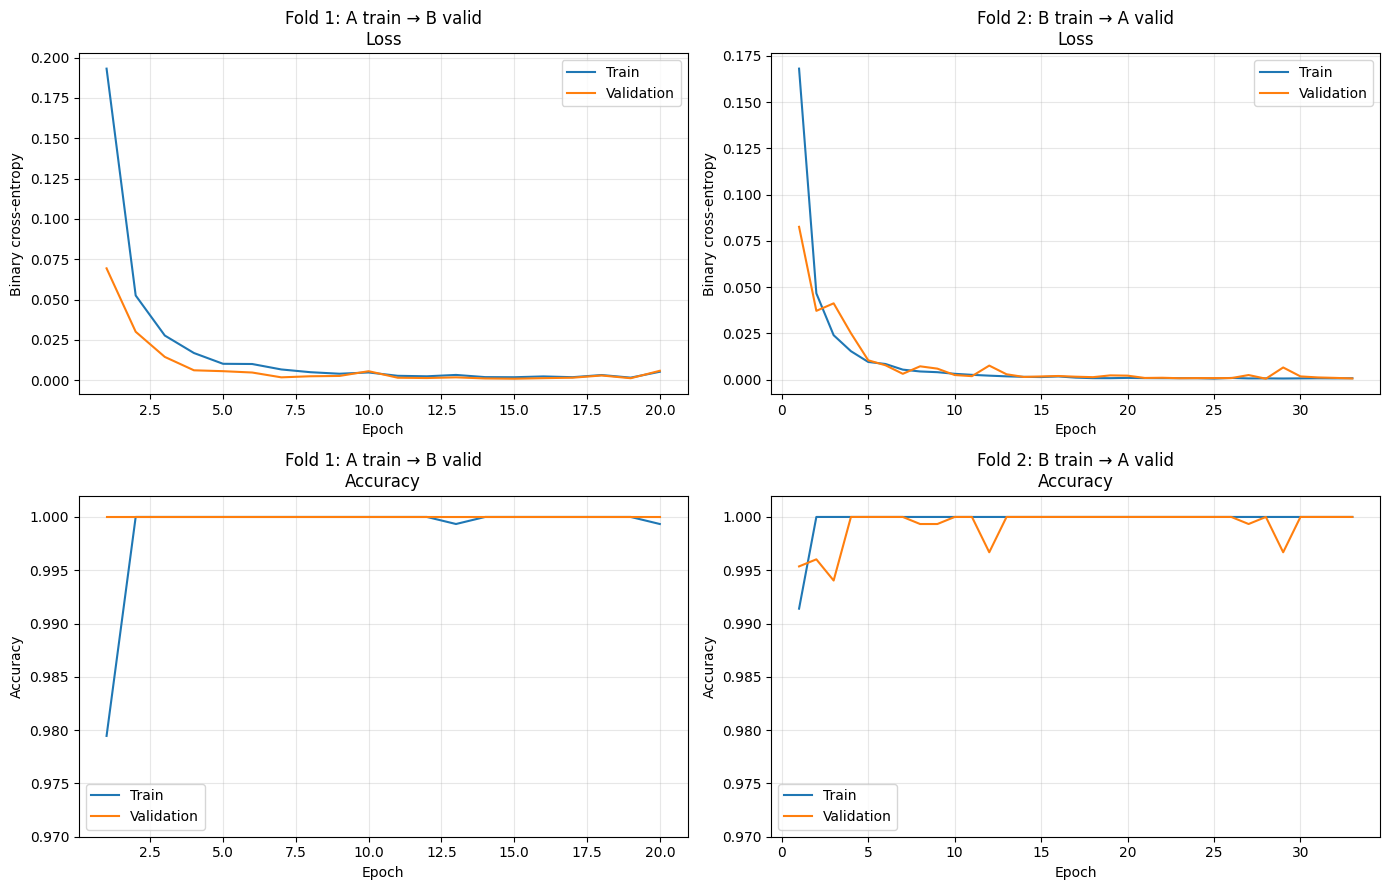

In [ ]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
)

fold_histories = [
    ("Fold 1: A train → B valid", history_fold_1),
    ("Fold 2: B train → A valid", history_fold_2),
]

for column, (title, history) in enumerate(
    fold_histories
):
    epochs = np.arange(
        1,
        len(history["train_loss"]) + 1,
    )

    axes[0, column].plot(
        epochs,
        history["train_loss"],
        label="Train",
    )
    axes[0, column].plot(
        epochs,
        history["valid_loss"],
        label="Validation",
    )
    axes[0, column].set_title(
        f"{title}\nLoss"
    )
    axes[0, column].set_xlabel("Epoch")
    axes[0, column].set_ylabel("Binary cross-entropy")
    axes[0, column].grid(alpha=0.3)
    axes[0, column].legend()

    axes[1, column].plot(
        epochs,
        history["train_accuracy"],
        label="Train",
    )
    axes[1, column].plot(
        epochs,
        history["valid_accuracy"],
        label="Validation",
    )
    axes[1, column].set_title(
        f"{title}\nAccuracy"
    )
    axes[1, column].set_xlabel("Epoch")
    axes[1, column].set_ylabel("Accuracy")
    axes[1, column].set_ylim(0.97, 1.002)
    axes[1, column].grid(alpha=0.3)
    axes[1, column].legend()

plt.tight_layout()
plt.show()

## 최적 모델의 confusion matrix와 확률 추출

Early Stopping으로 복원된 최적 모델을 사용한다.

검증 데이터의 실제 라벨, 예측 라벨과 ON 예측 확률을 추출하여 두 fold의 오분류 개수를 확인한다.

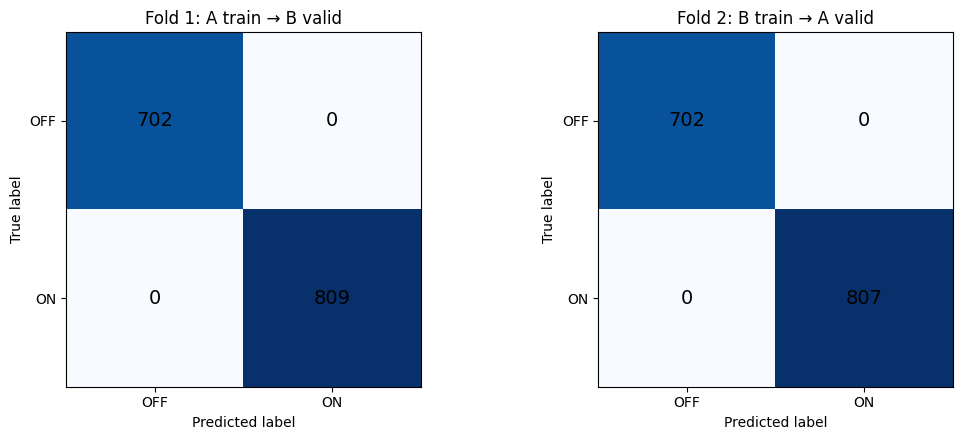

Fold 1 confusion matrix:
[[702   0]
 [  0 809]]

Fold 2 confusion matrix:
[[702   0]
 [  0 807]]


In [ ]:
from sklearn.metrics import confusion_matrix


def collect_predictions(model, data_loader):
    model.eval()

    labels = []
    probabilities = []

    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(device)

            logits = model(batch_X)
            batch_probabilities = torch.sigmoid(
                logits
            )

            labels.extend(
                batch_y.numpy()
            )
            probabilities.extend(
                batch_probabilities.cpu().numpy()
            )

    labels = np.asarray(labels).astype(np.int64)
    probabilities = np.asarray(probabilities)
    predictions = (
        probabilities >= 0.5
    ).astype(np.int64)

    return labels, predictions, probabilities


labels_fold_1, predictions_fold_1, probabilities_fold_1 = (
    collect_predictions(
        model_fold_1,
        valid_loader_fold_1,
    )
)

labels_fold_2, predictions_fold_2, probabilities_fold_2 = (
    collect_predictions(
        model_fold_2,
        valid_loader_fold_2,
    )
)

confusion_fold_1 = confusion_matrix(
    labels_fold_1,
    predictions_fold_1,
    labels=[0, 1],
)

confusion_fold_2 = confusion_matrix(
    labels_fold_2,
    predictions_fold_2,
    labels=[0, 1],
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
)

for axis, matrix, title in [
    (
        axes[0],
        confusion_fold_1,
        "Fold 1: A train → B valid",
    ),
    (
        axes[1],
        confusion_fold_2,
        "Fold 2: B train → A valid",
    ),
]:
    image_plot = axis.imshow(
        matrix,
        cmap="Blues",
    )

    for row in range(2):
        for column in range(2):
            axis.text(
                column,
                row,
                matrix[row, column],
                ha="center",
                va="center",
                fontsize=14,
            )

    axis.set_xticks([0, 1])
    axis.set_xticklabels(["OFF", "ON"])
    axis.set_yticks([0, 1])
    axis.set_yticklabels(["OFF", "ON"])
    axis.set_xlabel("Predicted label")
    axis.set_ylabel("True label")
    axis.set_title(title)

plt.tight_layout()
plt.show()

print("Fold 1 confusion matrix:")
print(confusion_fold_1)

print("\nFold 2 confusion matrix:")
print(confusion_fold_2)

## ON 예측 확률 분포

정확도만으로는 모델이 얼마나 확신 있게 분류하는지 알 수 없다.

OFF와 ON의 예측 확률이 0.5 주변에서 겹치는지 확인한다. 두 분포가 각각 0과 1 부근에 분리될수록 안정적인 분류 결과다.

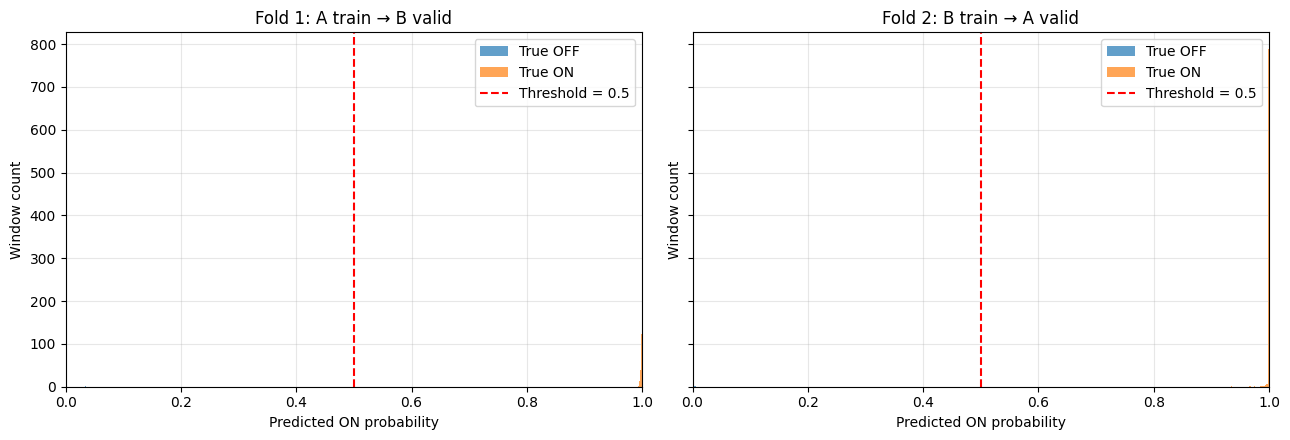

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
    sharey=True,
)

probability_results = [
    (
        axes[0],
        labels_fold_1,
        probabilities_fold_1,
        "Fold 1: A train → B valid",
    ),
    (
        axes[1],
        labels_fold_2,
        probabilities_fold_2,
        "Fold 2: B train → A valid",
    ),
]

for axis, labels, probabilities, title in probability_results:
    axis.hist(
        probabilities[labels == 0],
        bins=30,
        alpha=0.7,
        label="True OFF",
    )
    axis.hist(
        probabilities[labels == 1],
        bins=30,
        alpha=0.7,
        label="True ON",
    )

    axis.axvline(
        0.5,
        color="red",
        linestyle="--",
        label="Threshold = 0.5",
    )

    axis.set_title(title)
    axis.set_xlabel("Predicted ON probability")
    axis.set_ylabel("Window count")
    axis.set_xlim(0, 1)
    axis.grid(alpha=0.3)
    axis.legend()

plt.tight_layout()
plt.show()

## 실험별 교차검증 성능 확인

전체 정확도가 특정 실험의 많은 윈도우에 의해 높아진 것은 아닌지 확인한다.

각 검증 실험별로 정확도와 OFF/ON 윈도우 개수, 예측 확률 범위를 계산한다.

In [ ]:
def make_experiment_result_table(
    experiment_ids,
    labels,
    predictions,
    probabilities,
    fold_name,
):
    result = pd.DataFrame({
        "experiment_id": experiment_ids,
        "label": labels,
        "prediction": predictions,
        "on_probability": probabilities,
    })

    result["correct"] = (
        result["label"] == result["prediction"]
    )

    experiment_summary = (
        result.groupby("experiment_id")
        .agg(
            window_count=("label", "size"),
            off_count=(
                "label",
                lambda values: (values == 0).sum(),
            ),
            on_count=(
                "label",
                lambda values: (values == 1).sum(),
            ),
            accuracy=("correct", "mean"),
            min_on_probability=(
                "on_probability",
                "min",
            ),
            max_on_probability=(
                "on_probability",
                "max",
            ),
        )
        .reset_index()
    )

    experiment_summary.insert(
        0,
        "fold",
        fold_name,
    )

    return experiment_summary


fold_1_experiment_results = (
    make_experiment_result_table(
        development_b_cache["experiment_id"],
        labels_fold_1,
        predictions_fold_1,
        probabilities_fold_1,
        "A train → B valid",
    )
)

fold_2_experiment_results = (
    make_experiment_result_table(
        development_a_cache["experiment_id"],
        labels_fold_2,
        predictions_fold_2,
        probabilities_fold_2,
        "B train → A valid",
    )
)

cross_validation_experiment_results = pd.concat(
    [
        fold_1_experiment_results,
        fold_2_experiment_results,
    ],
    ignore_index=True,
)

display(cross_validation_experiment_results)

,fold,experiment_id,window_count,off_count,on_count,accuracy,min_on_probability,max_on_probability
0,A train → B valid,10,159,78,81,1.0,0.000057,0.999640
1,A train → B valid,11,162,78,84,1.0,0.000074,0.999714
2,A train → B valid,12,165,78,87,1.0,0.000061,0.999632
3,A train → B valid,13,165,78,87,1.0,0.000066,0.999634
4,A train → B valid,14,167,78,89,1.0,0.000071,0.999646
5,A train → B valid,15,171,78,93,1.0,0.000059,0.999711
6,A train → B valid,16,171,78,93,1.0,0.000077,0.999603
7,A train → B valid,17,174,78,96,1.0,0.000062,0.999613
8,A train → B valid,18,177,78,99,1.0,0.000061,0.999687
9,B train → A valid,1,159,78,81,1.0,0.000266,0.999946
